<a href="https://www.kaggle.com/code/joanwachuka/ksl-sign4?scriptVersionId=311516364" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization
# CONFIG (fixed to match your backend!)
DATA_PATH = "/kaggle/input/datasets/joanwachuka/ksl-hand-landmarks/dataset3/dataset2"
MAX_FRAMES = 40          # ← changed to match backend
FEATURES = 126
LABELS = ["fatherr", "hellor", "isr", "myr"]   # ← exact match with backend
EPOCHS = 15
BATCH_SIZE = 16
LEARNING_RATE = 0.001

# Load data (same as yours)
X, y = [], []
for label_idx, label in enumerate(LABELS):
    label_dir = os.path.join(DATA_PATH, label)
    for file in os.listdir(label_dir):
        if file.endswith('.npy'):
            seq = np.load(os.path.join(label_dir, file))
            X.append(seq)
            y.append(label_idx)

X = np.array(X, dtype=object)
y = np.array(y)

# Pad to MAX_FRAMES
X_padded = pad_sequences(X, maxlen=MAX_FRAMES, dtype='float32', padding='post', truncating='post')
y_onehot = to_categorical(y, num_classes=len(LABELS))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_padded, y_onehot, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape} | Labels: {LABELS}")

2026-04-14 12:18:17.554344: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776169097.734268      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776169097.784508      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776169098.197578      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776169098.197674      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776169098.197684      16 computation_placer.cc:177] computation placer alr

X_train shape: (654, 40, 126) | Labels: ['fatherr', 'hellor', 'isr', 'myr']


In [2]:
model = Sequential([
    Input(shape=(MAX_FRAMES, FEATURES)),
    LSTM(48, return_sequences=True,kernel_regularizer=l2(0.001)),   # smaller than 128
    BatchNormalization(),
    Dropout(0.6),
    
    LSTM(24, kernel_regularizer=l2(0.001)),
    BatchNormalization(),# smaller than 64
    Dropout(0.6),
    
    Dense(12, activation='relu', kernel_regularizer=l2(0.001)),
   
    Dense(len(LABELS), activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_ksl_model.keras', save_best_only=True)

model.summary()



2026-04-14 12:18:49.011446: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 40, 48)         │        33,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 48)         │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24)             │         7,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            52 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,248 (161.12 KB)

 Trainable params: 41,104 (160.56 KB)

 Non-trainable params: 144 (576.00 B)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.2963 - loss: 2.1282 - val_accuracy: 0.3130 - val_loss: 1.4714
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4312 - loss: 1.4819 - val_accuracy: 0.3817 - val_loss: 1.3767
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5609 - loss: 1.1537 - val_accuracy: 0.2672 - val_loss: 1.5950
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5558 - loss: 1.0867 - val_accuracy: 0.7634 - val_loss: 0.9837
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7407 - loss: 0.8313 - val_accuracy: 0.7634 - val_loss: 0.8345
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7771 - loss: 0.6807 - val_accuracy: 0.9389 - val_loss: 0.6495
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9007 - loss: 0.5618 - val_accuracy: 0.9847 - val_loss: 0.3695
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9504 - loss: 0.4337 - val_accuracy: 0.9695 - v

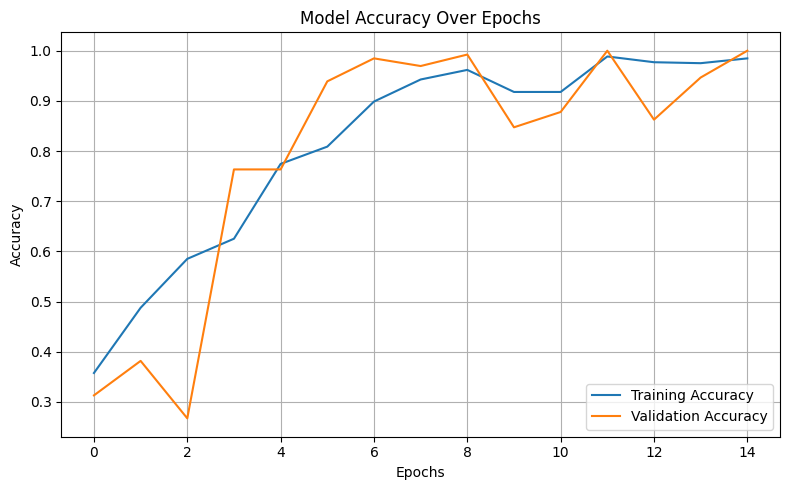

In [3]:

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    callbacks=[early_stop, checkpoint])

#accuracy chart
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
# Save full keras model just in case
model.save('ksl_model.keras')

# Convert to TFLite (lightweight version)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter.experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()

with open('ksl_model.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpkfikewq8/assets


INFO:tensorflow:Assets written to: /tmp/tmpkfikewq8/assets


Saved artifact at '/tmp/tmpkfikewq8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 126), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134104033619664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134104033620816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134104033620624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134104033622928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134104033621968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134104033621776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134104033623312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134104033622736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134104033623504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134104033622544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134104033622352: T

W0000 00:00:1776169152.324874      16 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776169152.324967      16 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1776169152.346280      16 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print(" Starting Model Evaluation...\n")

# ====================== 1. Evaluate on Test Set ======================
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(" FINAL TEST RESULTS")
print(f"Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss     : {test_loss:.4f}\n")

# ====================== 2. Get Predictions ======================
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# ====================== 3. Classification Report ======================
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true_classes, y_pred_classes, 
                            target_names=LABELS, 
                            digits=4))
print("="*60)


 Starting Model Evaluation...

 FINAL TEST RESULTS
Test Accuracy : 1.0000 (100.00%)
Test Loss     : 0.1406

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     fatherr     1.0000    1.0000    1.0000        40
      hellor     1.0000    1.0000    1.0000        40
         isr     1.0000    1.0000    1.0000        42
         myr     1.0000    1.0000    1.0000        42

    accuracy                         1.0000       164
   macro avg     1.0000    1.0000    1.0000       164
weighted avg     1.0000    1.0000    1.0000       164



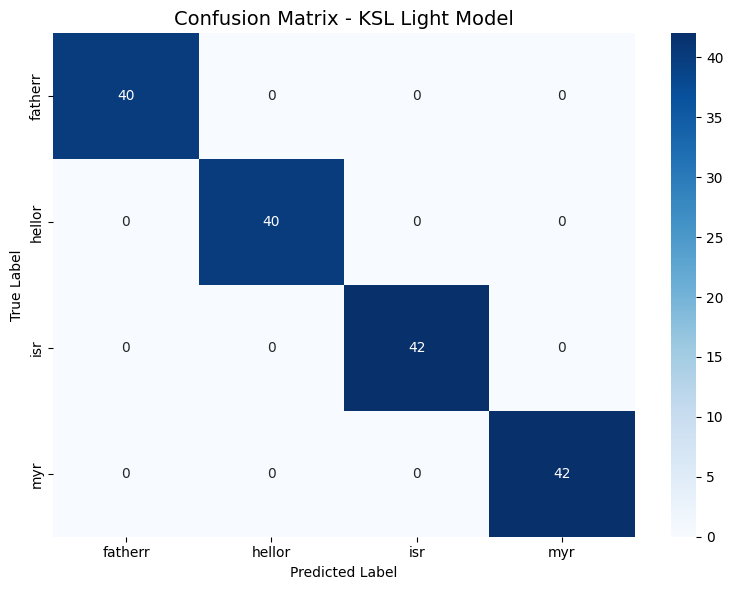

In [6]:
# ====================== 4. Confusion Matrix + Heatmap ======================
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=LABELS, 
            yticklabels=LABELS, 
            cbar=True)

plt.title('Confusion Matrix - KSL Light Model', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [7]:


# ====================== 5. Per-Class Accuracy ======================
print("\n PER-CLASS ACCURACY")
print("-" * 50)
for i, label in enumerate(LABELS):
    correct = cm[i, i]
    total = cm[i].sum()
    acc = correct / total if total > 0 else 0
    print(f"{label:12} : {acc:.4f}  ({acc*100:5.2f}%)   [{correct}/{total}]")

# ====================== 6. Overall Summary ======================
print("\n" + "="*60)
print(f"OVERALL TEST ACCURACY: {test_accuracy*100:.2f}%")
print(f"Number of test samples: {len(X_test)}")
print("="*60)




 PER-CLASS ACCURACY
--------------------------------------------------
fatherr      : 1.0000  (100.00%)   [40/40]
hellor       : 1.0000  (100.00%)   [40/40]
isr          : 1.0000  (100.00%)   [42/42]
myr          : 1.0000  (100.00%)   [42/42]

OVERALL TEST ACCURACY: 100.00%
Number of test samples: 164



OVERALL TEST ACCURACY: 100.00%
Number of test samples: 164


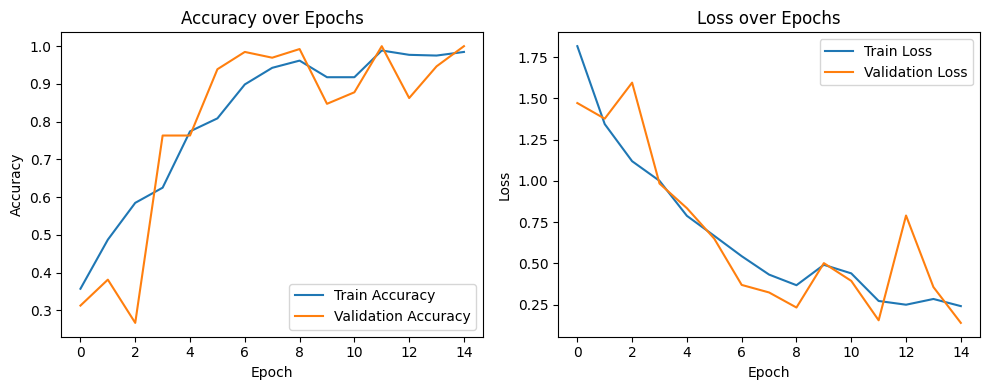

In [8]:
# ====================== 6. Overall Summary ======================
print("\n" + "="*60)
print(f"OVERALL TEST ACCURACY: {test_accuracy*100:.2f}%")
print(f"Number of test samples: {len(X_test)}")
print("="*60)

# Optional: Plot training history if you have 'history'
if 'history' in locals():
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()